In [1]:
import tensorflow
from tensorflow import keras
from keras.layers import Dense,Conv2D,Flatten,MaxPooling2D,Dropout
from keras import Sequential
from keras.datasets import mnist

In [2]:
(X_train,y_train),(X_test,y_test)=mnist.load_data()

In [3]:
X_train.shape

(60000, 28, 28)

In [4]:
X_test.shape

(10000, 28, 28)

Reshaping Inputs

In [5]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

Normalising Inputs

In [6]:
X_train=X_train/255
X_test=X_test/255

Cnn(Baseline)

In [7]:
model=Sequential()
model.add(Conv2D(32,kernel_size=(3,3),padding='same',activation='relu',input_shape=(28,28,1)))
model.add(Conv2D(64,kernel_size=(3,3),padding='same'))
model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dense(10,activation='softmax'))

In [8]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 28, 28, 32)        320       
                                                                 
 conv2d_1 (Conv2D)           (None, 28, 28, 64)        18496     
                                                                 
 flatten (Flatten)           (None, 50176)             0         
                                                                 
 dense (Dense)               (None, 128)               6422656   
                                                                 
 dense_1 (Dense)             (None, 10)                1290      
                                                                 
Total params: 6,442,762
Trainable params: 6,442,762
Non-trainable params: 0
_________________________________________________________________


In [9]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [10]:
history = model.fit( X_train, y_train, epochs=10, batch_size=64, validation_split=0.2)

Epoch 1/10
750/750 [==============================] - 13s 9ms/step - loss: 0.1330 - accuracy: 0.9592 - val_loss: 0.0585 - val_accuracy: 0.9831
Epoch 2/10
750/750 [==============================] - 6s 8ms/step - loss: 0.0418 - accuracy: 0.9862 - val_loss: 0.0538 - val_accuracy: 0.9845
Epoch 3/10
750/750 [==============================] - 6s 8ms/step - loss: 0.0278 - accuracy: 0.9908 - val_loss: 0.0604 - val_accuracy: 0.9825
Epoch 4/10
750/750 [==============================] - 6s 8ms/step - loss: 0.0196 - accuracy: 0.9936 - val_loss: 0.0554 - val_accuracy: 0.9862
Epoch 5/10
750/750 [==============================] - 6s 8ms/step - loss: 0.0145 - accuracy: 0.9951 - val_loss: 0.0582 - val_accuracy: 0.9859
Epoch 6/10
750/750 [==============================] - 6s 8ms/step - loss: 0.0146 - accuracy: 0.9952 - val_loss: 0.0752 - val_accuracy: 0.9819
Epoch 7/10
750/750 [==============================] - 6s 8ms/step - loss: 0.0148 - accuracy: 0.9953 - val_loss: 0.0713 - val_accuracy: 0.9836
Epoch

In [11]:
y_prob=model.predict(X_test)
y_pred=y_prob.argmax(axis=1)

313/313 [==============================] - 1s 2ms/step


In [12]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9858

Baseline Acc(0.9834)

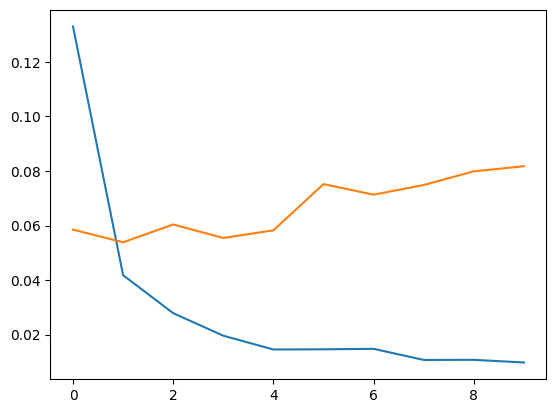

In [15]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

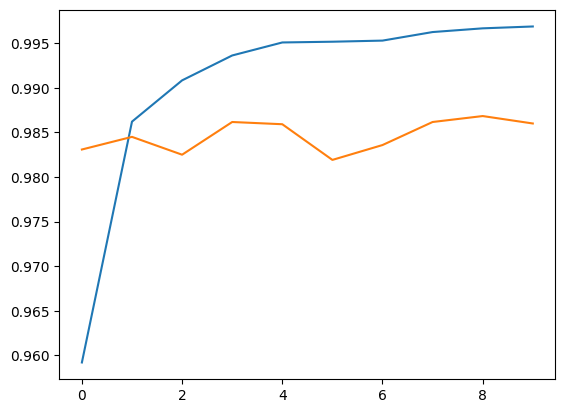

In [16]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

Tuning the Cnn

In [18]:
from keras.layers import BatchNormalization,Activation
from keras.callbacks import EarlyStopping,ReduceLROnPlateau
model1=Sequential()
model1.add(Conv2D(32,kernel_size=(3,3),padding='same',input_shape=(28,28,1)))
model1.add(BatchNormalization())
model1.add(Activation('relu'))
model1.add(MaxPooling2D(pool_size=(2,2)))

model1.add(Conv2D(64,kernel_size=(3,3),padding='same'))
model1.add(BatchNormalization())
model1.add(Activation('relu'))
model1.add(MaxPooling2D(pool_size=(2,2)))

model1.add(Conv2D(128, (3,3), padding='same'))
model1.add(BatchNormalization())
model1.add(Activation('relu'))

model1.add(Flatten())

model1.add(Dense(128))
model1.add(BatchNormalization())
model1.add(Activation('relu'))
model1.add(Dropout(0.3))

model1.add(Dense(10,activation='softmax'))

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-5
)

In [19]:
model1.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_5 (Conv2D)           (None, 28, 28, 32)        320       
                                                                 
 batch_normalization_2 (Batc  (None, 28, 28, 32)       128       
 hNormalization)                                                 
                                                                 
 activation_2 (Activation)   (None, 28, 28, 32)        0         
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 14, 14, 32)       0         
 2D)                                                             
                                                                 
 conv2d_6 (Conv2D)           (None, 14, 14, 64)        18496     
                                                                 
 batch_normalization_3 (Batc  (None, 14, 14, 64)      

In [20]:
model1.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [21]:
history1= model1.fit( X_train, y_train, epochs=30, batch_size=64, validation_split=0.2,callbacks=[early_stop, lr_scheduler])

Epoch 1/30
750/750 [==============================] - 6s 7ms/step - loss: 0.1109 - accuracy: 0.9691 - val_loss: 0.0544 - val_accuracy: 0.9832 - lr: 0.0010
Epoch 2/30
750/750 [==============================] - 5s 7ms/step - loss: 0.0456 - accuracy: 0.9870 - val_loss: 0.0324 - val_accuracy: 0.9906 - lr: 0.0010
Epoch 3/30
750/750 [==============================] - 5s 7ms/step - loss: 0.0328 - accuracy: 0.9897 - val_loss: 0.1020 - val_accuracy: 0.9687 - lr: 0.0010
Epoch 4/30
750/750 [==============================] - 5s 7ms/step - loss: 0.0272 - accuracy: 0.9918 - val_loss: 0.0296 - val_accuracy: 0.9908 - lr: 0.0010
Epoch 5/30
750/750 [==============================] - 5s 6ms/step - loss: 0.0213 - accuracy: 0.9929 - val_loss: 0.0302 - val_accuracy: 0.9908 - lr: 0.0010
Epoch 6/30
750/750 [==============================] - 5s 6ms/step - loss: 0.0198 - accuracy: 0.9933 - val_loss: 0.0336 - val_accuracy: 0.9894 - lr: 0.0010
Epoch 7/30
750/750 [==============================] - 5s 6ms/step - lo

In [23]:
y_prob1=model1.predict(X_test)
y_pred1=y_prob1.argmax(axis=1)
accuracy_score(y_test,y_pred1)

313/313 [==============================] - 1s 2ms/step


0.9938

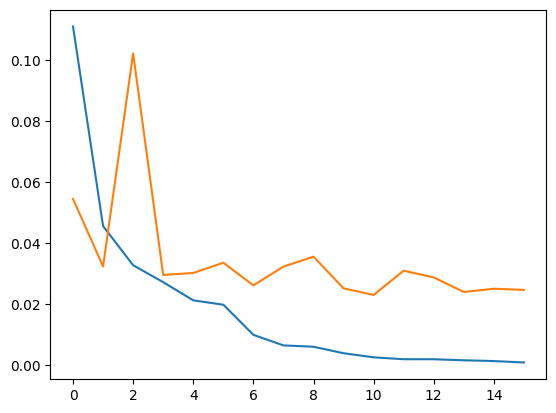

In [24]:
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])

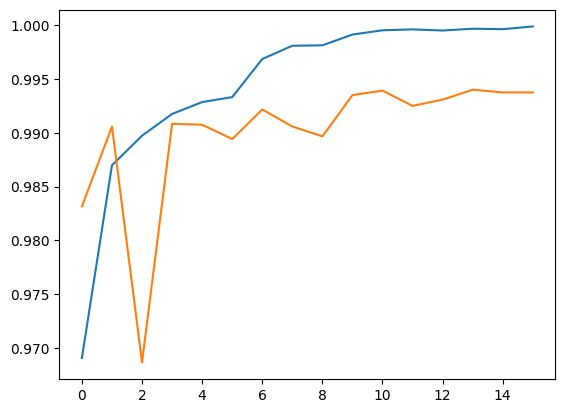

In [25]:
plt.plot(history1.history['accuracy'])
plt.plot(history1.history['val_accuracy'])